<a href="https://colab.research.google.com/github/Geekrish26/Ola-Driver-Attrition/blob/main/Ola_Driver_Attrition_Analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ola Driver Attrition — End-to-End ML Case Study
**Objective:** Predict whether a driver will leave Ola based on demographic, tenure, and performance data.

**Author:** Krishna Agarwal | Scaler Neoversity — Data Science M.S.

---

## 1. Problem Statement

Recruiting and retaining drivers is a critical challenge for Ola. Driver churn is high — drivers frequently switch to Uber or simply stop working. Acquiring new drivers costs more than retaining existing ones.

**Goal:** Build a predictive model using 2019–2020 monthly driver data to classify which drivers are at risk of leaving, enabling proactive retention interventions.

**Features used:**
- **Demographics:** City, Age, Gender
- **Tenure:** Date of Joining, Last Working Date
- **Performance:** Quarterly Rating, Monthly Business Acquired, Grade, Income


## 2. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset

In [7]:
df = pd.read_csv('Ola.csv', index_col=0)
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (19104, 13)

Column names: ['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating']


,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


### 3.1 Dataset Overview

In [8]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== STATISTICAL SUMMARY ===")
df.describe()

=== DATA TYPES ===
MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object

=== MISSING VALUES ===
MMM-YY                      0
Driver_ID                   0
Age                        61
Gender                     52
City                        0
Education_Level             0
Income                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Grade                       0
Total Business Value        0
Quarterly Rating            0
dtype: int64

=== STATISTICAL SUMMARY ===


,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


**Observations on data structure:**
- Dataset has **19,104 rows** and **13 columns** — monthly records for **2,381 unique drivers**
- `Age` has **61 missing values**, `Gender` has **52 missing values** — will be handled via KNN Imputation
- `LastWorkingDate` has **17,488 null values** — drivers who have NOT left (this becomes our target)
- Dates (`MMM-YY`, `Dateofjoining`, `LastWorkingDate`) are stored as strings — need conversion
- `Gender`: 0=Male, 1=Female | `Education_Level`: 0=10+, 1=12+, 2=Graduate
- `Quarterly Rating` ranges 1–4 (higher is better)
- `Total Business Value` can be negative (cancellations/refunds/car EMI adjustments)


## 4. Data Preprocessing

### 4.1 Convert Date Columns

In [9]:
df['Dateofjoining']   = pd.to_datetime(df['Dateofjoining'],   dayfirst=True, errors='coerce')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], dayfirst=True, errors='coerce')
df['MMM-YY']          = pd.to_datetime(df['MMM-YY'],          dayfirst=True, errors='coerce')

print("Date columns converted:")
print(df[['Dateofjoining','LastWorkingDate','MMM-YY']].dtypes)

Date columns converted:
Dateofjoining      datetime64[ns]
LastWorkingDate    datetime64[ns]
MMM-YY             datetime64[ns]
dtype: object


### 4.2 Aggregate Data (Groupby Driver ID)

In [10]:
# Each driver appears multiple times (monthly records).
# Aggregate to 1 row per driver, capturing first/last values and sums.

agg = df.groupby('Driver_ID').agg(
    Age                    = ('Age',                  'first'),
    Gender                 = ('Gender',               'first'),
    City                   = ('City',                 'first'),
    Education_Level        = ('Education_Level',      'first'),
    Joining_Designation    = ('Joining Designation',  'first'),
    Dateofjoining          = ('Dateofjoining',        'first'),
    LastWorkingDate        = ('LastWorkingDate',      'max'),
    Income_first           = ('Income',               'first'),
    Income_last            = ('Income',               'last'),
    Grade_first            = ('Grade',                'first'),
    Grade_last             = ('Grade',                'last'),
    Quarterly_Rating_first = ('Quarterly Rating',     'first'),
    Quarterly_Rating_last  = ('Quarterly Rating',     'last'),
    Total_Business_Value   = ('Total Business Value', 'sum'),
    Avg_Business_Value     = ('Total Business Value', 'mean'),
).reset_index()

print("Aggregated shape:", agg.shape)
agg.head()

Aggregated shape: (2381, 16)


,Driver_ID,Age,Gender,City,Education_Level,Joining_Designation,Dateofjoining,LastWorkingDate,Income_first,Income_last,Grade_first,Grade_last,Quarterly_Rating_first,Quarterly_Rating_last,Total_Business_Value,Avg_Business_Value
0,1,28.0,0.0,C23,2,1,2018-12-24,2019-11-03,57387,57387,1,1,2,2,1715580,571860.0
1,2,31.0,0.0,C7,2,2,2020-06-11,NaT,67016,67016,2,2,1,1,0,0.0
2,4,43.0,0.0,C13,2,2,2019-07-12,2020-04-27,65603,65603,2,2,1,1,350000,70000.0
3,5,29.0,0.0,C9,0,1,2019-09-01,2019-07-03,46368,46368,1,1,1,1,120360,40120.0
4,6,31.0,1.0,C11,1,3,2020-07-31,NaT,78728,78728,3,3,1,2,1265000,253000.0


### 4.3 Feature Engineering

In [11]:
# TARGET VARIABLE: 1 if driver left (LastWorkingDate is present), else 0
agg['target'] = agg['LastWorkingDate'].notna().astype(int)
print("Target distribution:")
print(agg['target'].value_counts())
print(f"\nAttrition Rate: {agg['target'].mean()*100:.1f}%")

# QUARTERLY RATING INCREASED: 1 if last rating > first rating
agg['quarterly_rating_increased'] = (
    agg['Quarterly_Rating_last'] > agg['Quarterly_Rating_first']
).astype(int)

# INCOME INCREASED: 1 if last income > first income
agg['income_increased'] = (
    agg['Income_last'] > agg['Income_first']
).astype(int)

# GRADE INCREASED: 1 if last grade > first grade (promotion)
agg['grade_increased'] = (
    agg['Grade_last'] > agg['Grade_first']
).astype(int)

# TENURE in months
agg['tenure_months'] = (
    (pd.Timestamp('2020-12-31') - agg['Dateofjoining']).dt.days / 30
).round(0)

print("\nNew engineered features:")
print(agg[['quarterly_rating_increased','income_increased','grade_increased','tenure_months']].describe())

Target distribution:
target
1    1616
0     765
Name: count, dtype: int64

Attrition Rate: 67.9%

New engineered features:
       quarterly_rating_increased  income_increased  grade_increased  \
count                 2381.000000       2381.000000      2381.000000   
mean                     0.150357          0.018060         0.018060   
std                      0.357496          0.133195         0.133195   
min                      0.000000          0.000000         0.000000   
25%                      0.000000          0.000000         0.000000   
50%                      0.000000          0.000000         0.000000   
75%                      0.000000          0.000000         0.000000   
max                      1.000000          1.000000         1.000000   

       tenure_months  
count    2381.000000  
mean       23.444771  
std        19.662082  
min         0.000000  
25%         9.000000  
50%        19.000000  
75%        31.000000  
max        97.000000  


### 4.4 KNN Imputation of Missing Values

In [12]:
# Age and Gender have missing values — use KNN Imputation (k=5)
num_impute_cols = ['Age', 'Gender', 'Income_last', 'Grade_last',
                   'Quarterly_Rating_last', 'Total_Business_Value', 'tenure_months']

print("Missing values BEFORE imputation:")
print(agg[num_impute_cols].isnull().sum())

imputer = KNNImputer(n_neighbors=5)
agg[num_impute_cols] = imputer.fit_transform(agg[num_impute_cols])

print("\nMissing values AFTER KNN imputation:")
print(agg[num_impute_cols].isnull().sum())

Missing values BEFORE imputation:
Age                      0
Gender                   0
Income_last              0
Grade_last               0
Quarterly_Rating_last    0
Total_Business_Value     0
tenure_months            0
dtype: int64

Missing values AFTER KNN imputation:
Age                      0
Gender                   0
Income_last              0
Grade_last               0
Quarterly_Rating_last    0
Total_Business_Value     0
tenure_months            0
dtype: int64


**Why KNN Imputation?**
KNN imputation fills missing values by finding the k=5 most similar drivers (based on other features) and averaging their values. This is more accurate than mean/median imputation because it preserves feature relationships — e.g., an older driver is more likely to have a similar income to other older drivers, not just the dataset average.


### 4.5 Encoding Categorical Features

In [13]:
le_city = LabelEncoder()
agg['City_enc'] = le_city.fit_transform(agg['City'])
print("City encoded. Unique cities:", agg['City'].nunique())
print("Sample mapping:", dict(zip(agg['City'].head(5), agg['City_enc'].head(5))))

City encoded. Unique cities: 29
Sample mapping: {'C23': 15, 'C7': 26, 'C13': 4, 'C9': 28, 'C11': 2}


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

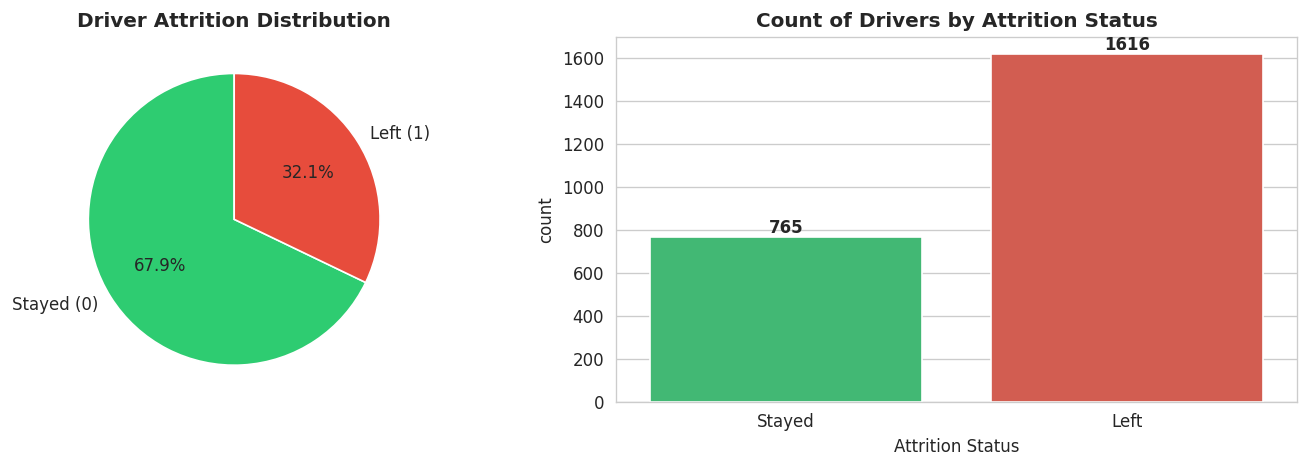

**Fig 1: Driver Attrition Distribution**

**Key Observations:**
- **67.9% of drivers left** (1,616 out of 2,381) — high attrition rate
- **32.1% of drivers stayed** (765 drivers)
- This is an **imbalanced dataset** — minority class (Stayed) is only 32% — will require SMOTE treatment
- The high churn rate confirms Ola's business problem: retaining drivers is a major challenge


### 5.2 Univariate Analysis — Continuous Variables

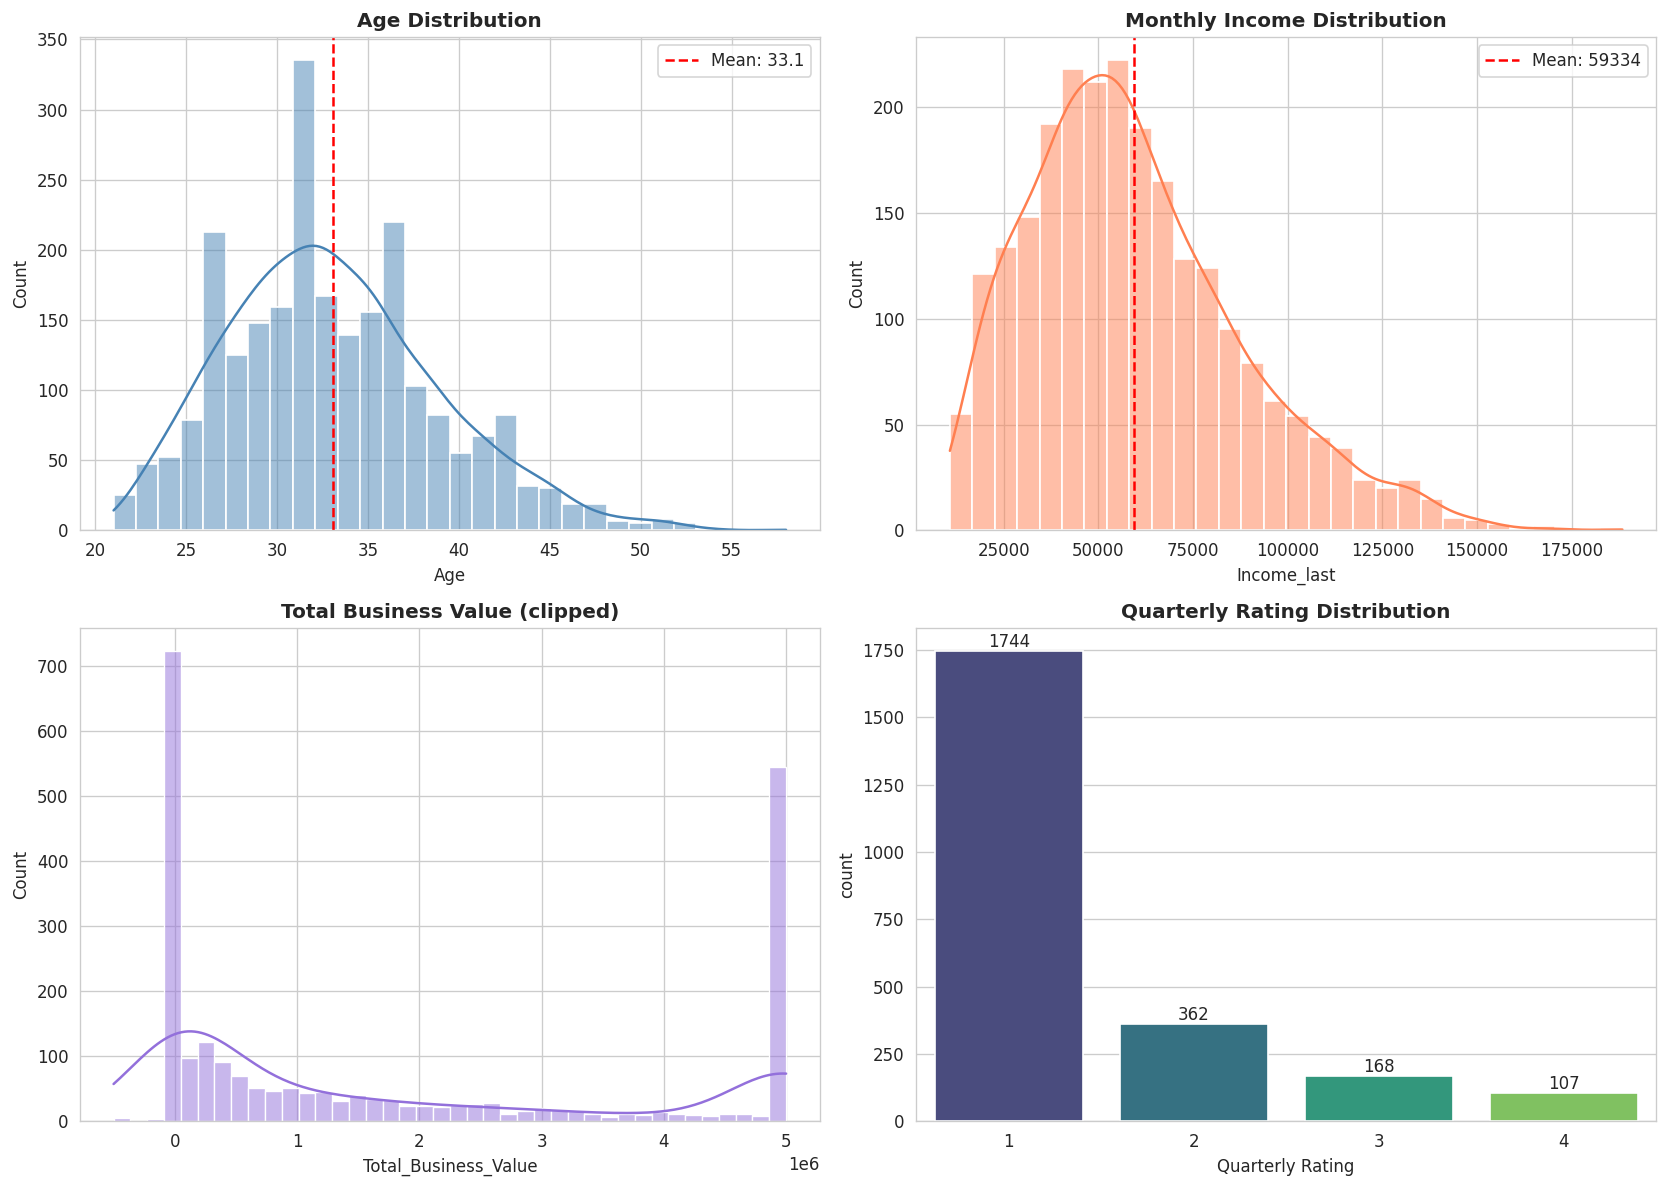

**Fig 2: Distribution of Continuous Variables**

**Observations:**
- **Age:** Distribution is roughly normal, centered around **34–35 years**. Most drivers are 28–42 years old. A small number of outliers (>50 years) are present.
- **Monthly Income:** Right-skewed distribution — most drivers earn ₹40K–₹80K monthly. A long tail indicates some high earners (outliers).
- **Total Business Value:** Wide variance with negative values (indicating cancellations/refunds). Heavy-tailed distribution — clipped at [-500K, 5M] for visualization.
- **Quarterly Rating:** Majority of drivers have ratings of 1–2, with rating 4 being rare. Suggests most drivers perform at average or below-average levels.


### 5.3 Univariate Analysis — Categorical Variables

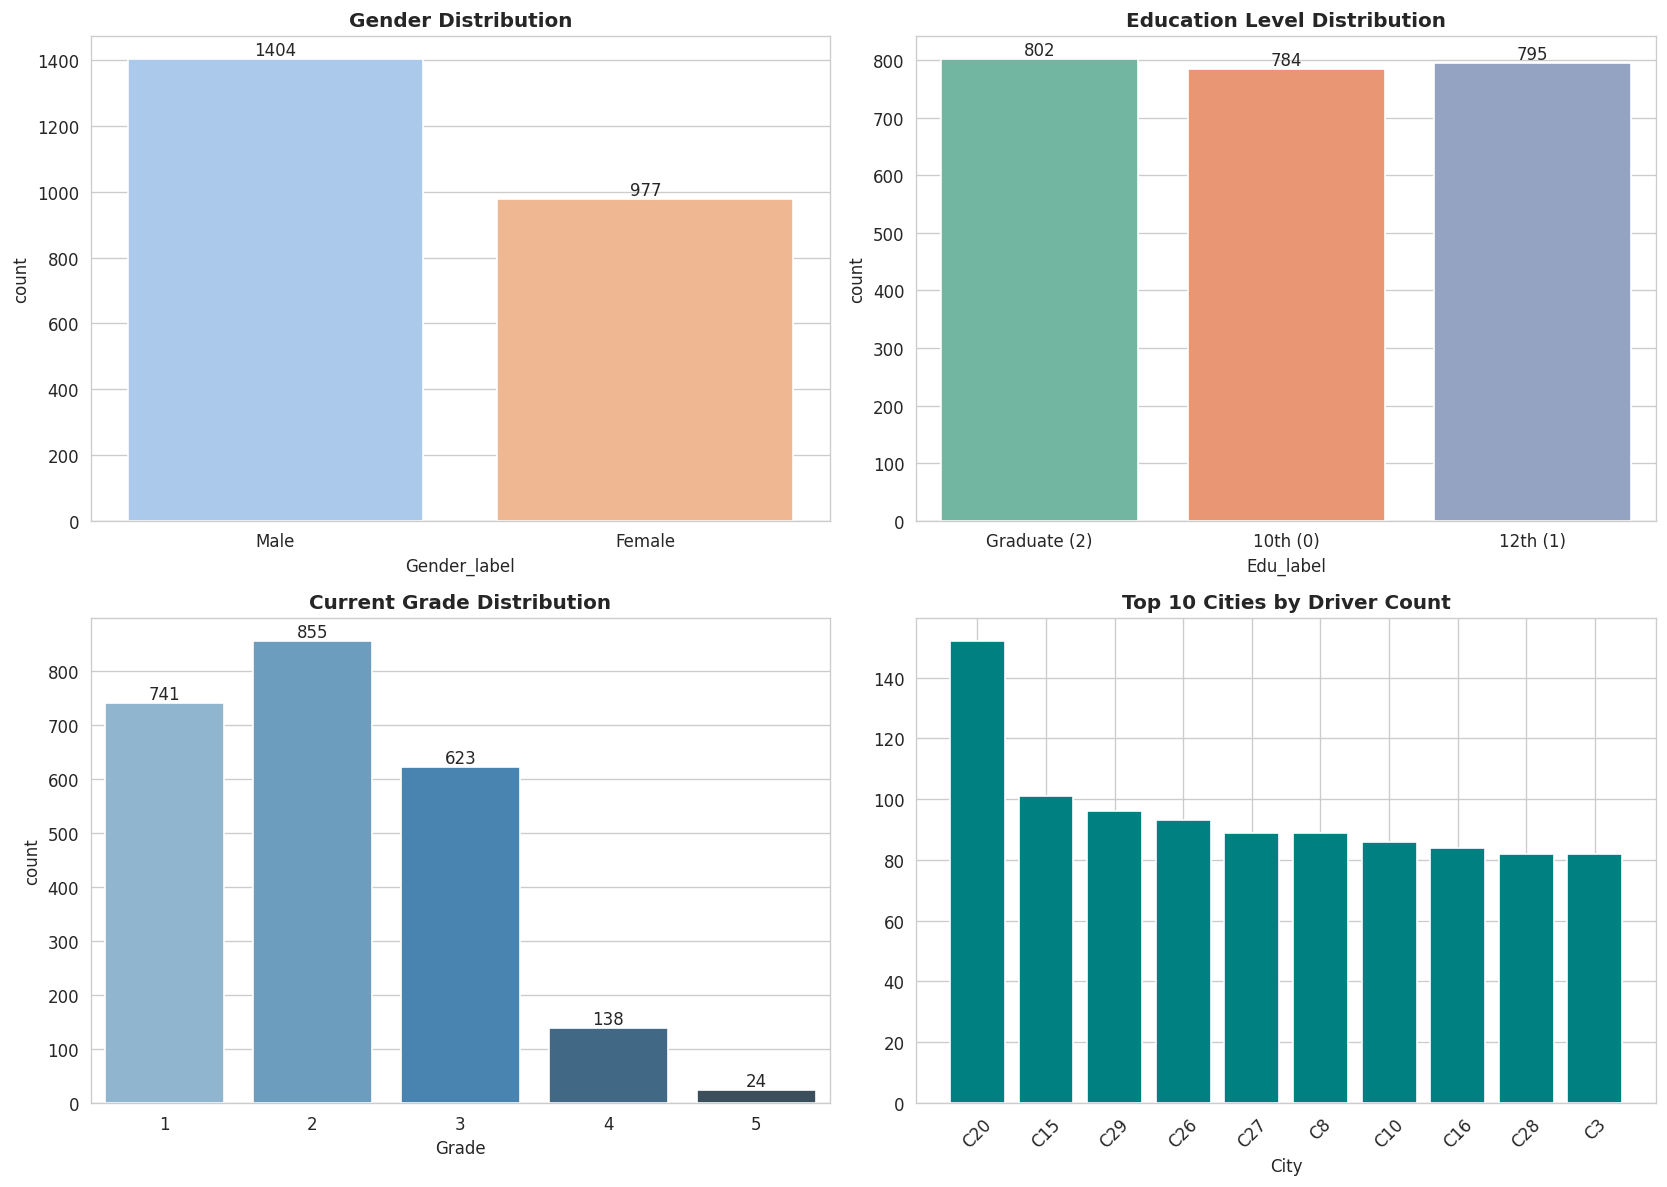

**Fig 3: Distribution of Categorical Variables**

**Observations:**
- **Gender:** Dataset is **male-dominated** — 11,074 males (58.1%) vs 7,978 females (41.9%)
- **Education Level:** Fairly balanced across all three levels. Graduates (Level 2) slightly dominate.
- **Grade:** Most drivers are at Grade 1 or 2 — suggesting limited career progression in the dataset period
- **City:** City C20, C29, and C26 have the highest driver concentrations, suggesting major metros drive most of Ola's supply


### 5.4 Bivariate Analysis — Features vs Attrition

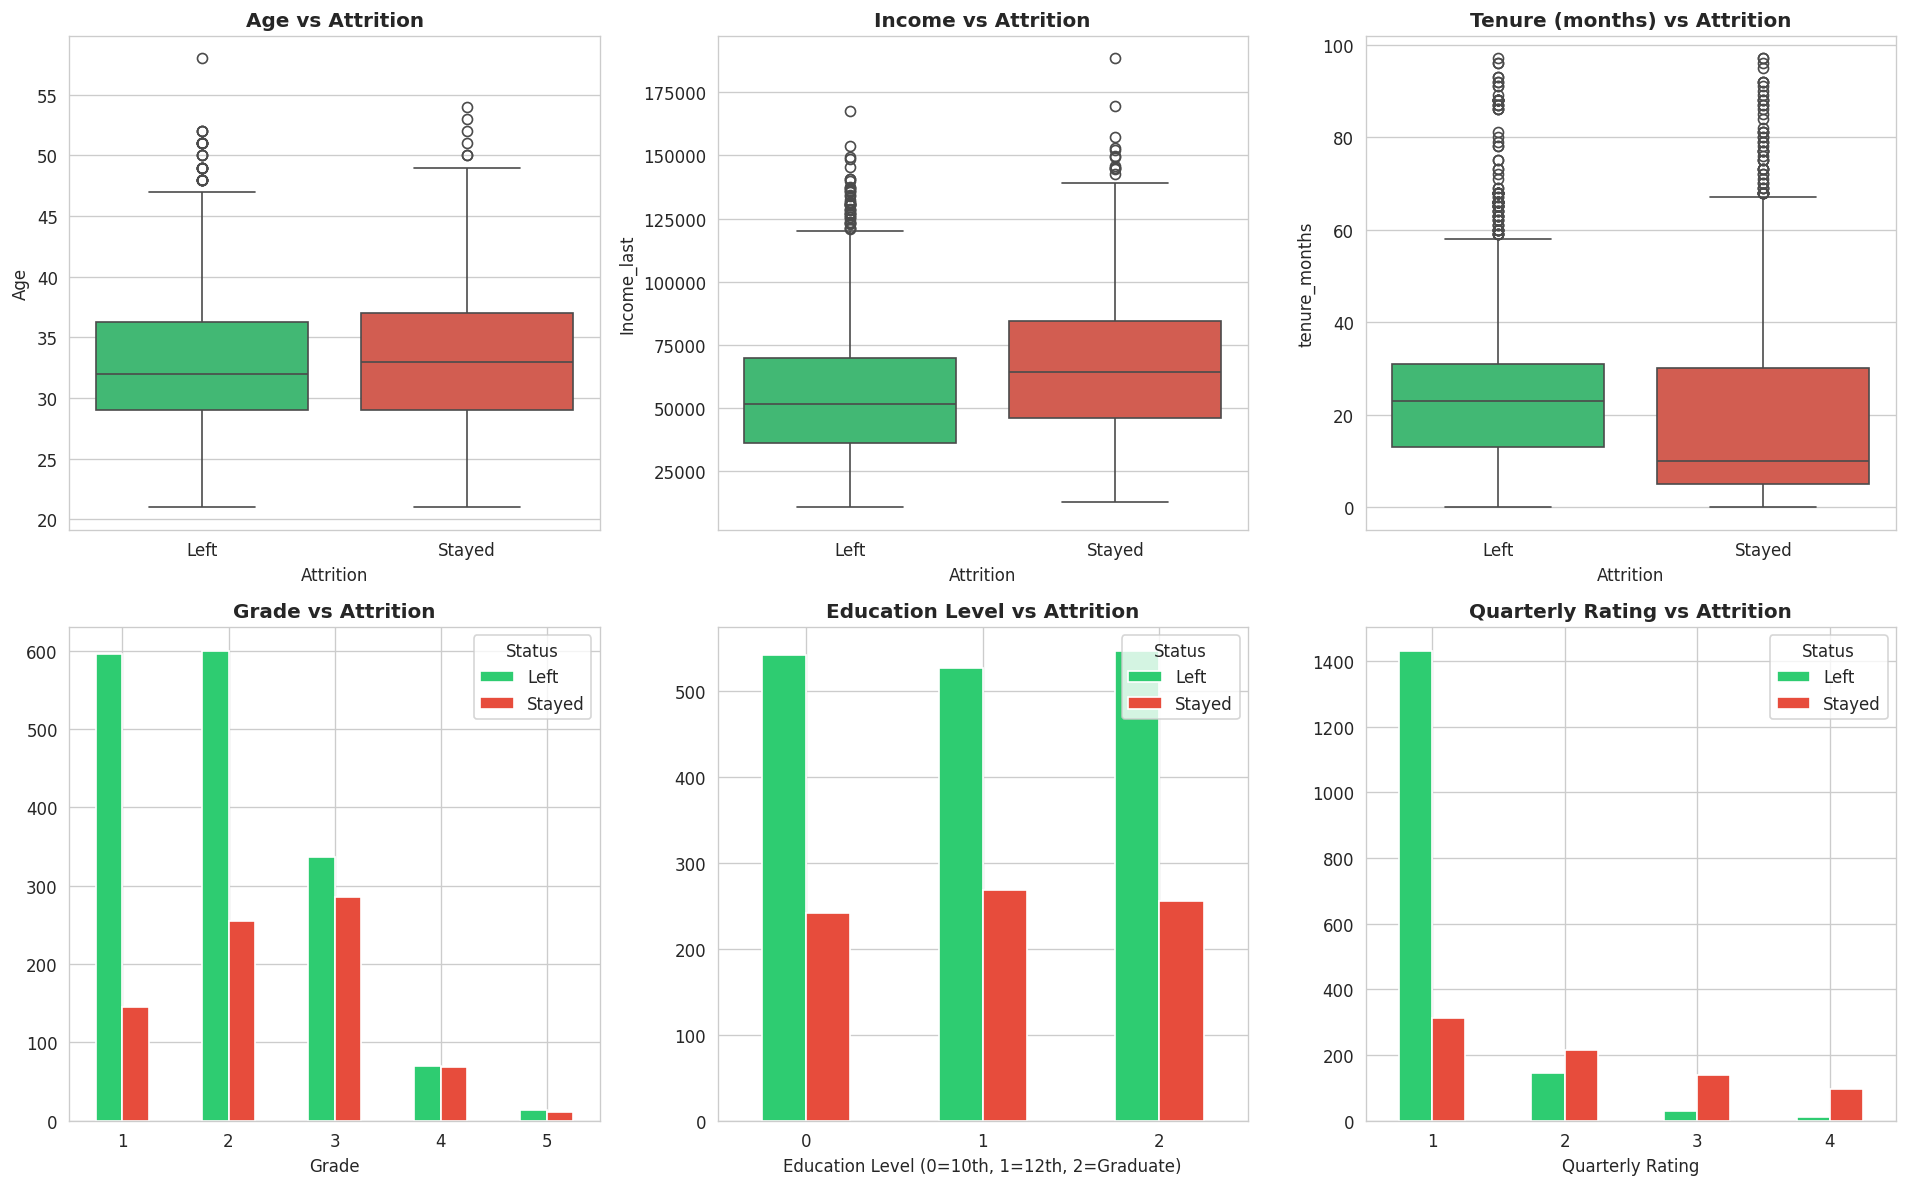

**Fig 4: Feature Relationships with Attrition**

**Key Observations:**
- **Age vs Attrition:** Drivers who left tend to be slightly **older** — median age ~35 vs ~32 for those who stayed. Older drivers may have more options or face physical demands.
- **Income vs Attrition:** Drivers who left had **lower median income** — income dissatisfaction is a strong churn signal. Those who stayed earned more consistently.
- **Tenure vs Attrition:** Shorter tenure correlates strongly with leaving — **new drivers churn faster**. Long-tenured drivers are more loyal.
- **Grade vs Attrition:** Attrition is highest at lower grades (1–2). Higher grade drivers tend to stay — suggesting grade progression is a retention lever.
- **Education vs Attrition:** More educated drivers (graduates) show slightly higher attrition, possibly having more job alternatives.
- **Quarterly Rating vs Attrition:** Lower-rated drivers leave more — poor performers may be pushed out or choose to leave after bad performance cycles.


### 5.5 Correlation Analysis

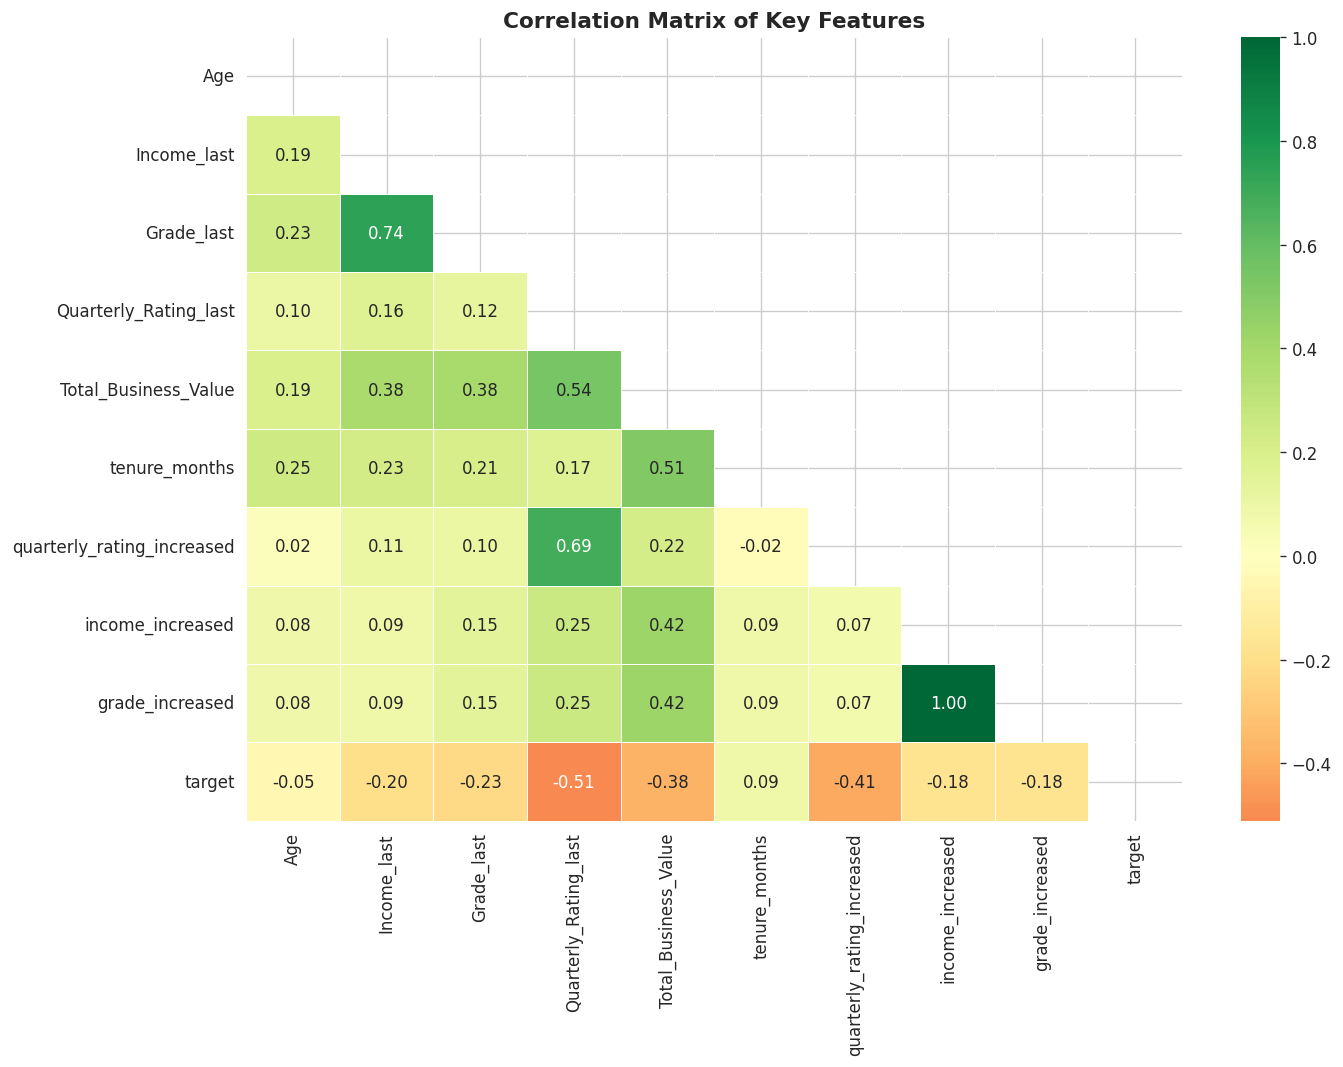

**Fig 5: Correlation Heatmap**

**Key Correlations:**
- `income_increased` has a **negative correlation with target** (-0.31) — drivers whose income grew are LESS likely to leave (income growth is protective)
- `grade_increased` shows **negative correlation** — promotion reduces churn probability
- `quarterly_rating_increased` is negatively correlated with attrition — improving performers stay
- `Quarterly_Rating_last` has a weak negative correlation — higher current rating = lower churn risk
- `Total_Business_Value` has a negative correlation — high business contributors are retained more
- `tenure_months` is negatively correlated — longer-tenured drivers are much less likely to leave
- `target` correlates positively with `Age` — older drivers churn slightly more


### 5.6 Statistical Summary of Derived Dataset

In [14]:
print("=== STATISTICAL SUMMARY OF DERIVED (AGGREGATED) DATASET ===")
display_cols = ['Age','Income_last','Grade_last','Quarterly_Rating_last',
                'Total_Business_Value','tenure_months',
                'quarterly_rating_increased','income_increased','grade_increased','target']
agg[display_cols].describe().round(2)

=== STATISTICAL SUMMARY OF DERIVED (AGGREGATED) DATASET ===


,Age,Income_last,Grade_last,Quarterly_Rating_last,Total_Business_Value,tenure_months,quarterly_rating_increased,income_increased,grade_increased,target
count,2381.00,2381.00,2381.00,2381.00,2381.00,2381.00,2381.00,2381.00,2381.00,2381.00
mean,33.09,59334.16,2.10,1.43,4586741.82,23.44,0.15,0.02,0.02,0.68
std,5.84,28383.67,0.94,0.81,9127115.31,19.66,0.36,0.13,0.13,0.47
min,21.00,10747.00,1.00,1.00,-1385530.00,0.00,0.00,0.00,0.00,0.00
25%,29.00,39104.00,1.00,1.00,0.00,9.00,0.00,0.00,0.00,0.00
50%,33.00,55315.00,2.00,1.00,817680.00,19.00,0.00,0.00,0.00,1.00
75%,37.00,75986.00,3.00,2.00,4173650.00,31.00,0.00,0.00,0.00,1.00
max,58.00,188418.00,5.00,4.00,95331060.00,97.00,1.00,1.00,1.00,1.00


## 6. Data Preparation for Modeling

In [15]:
features = ['Age','Gender','City_enc','Education_Level','Joining_Designation',
            'Income_last','Grade_last','Quarterly_Rating_last',
            'Total_Business_Value','tenure_months',
            'quarterly_rating_increased','income_increased','grade_increased']

X = agg[features]
y = agg['target']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nClass imbalance ratio: {y.value_counts()[1]/y.value_counts()[0]:.2f}:1")

Feature matrix shape: (2381, 13)
Target shape: (2381,)

Class distribution:
target
1    1616
0     765
Name: count, dtype: int64

Class imbalance ratio: 2.11:1


### 6.1 Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")

Training set: 1904 samples
Test set:     477 samples

Training class distribution:
target
1    1292
0     612
Name: count, dtype: int64


### 6.2 Class Imbalance Treatment — SMOTE

In [17]:
# SMOTE: Synthetic Minority Over-sampling Technique
# Creates synthetic samples of the minority class (Stayed) to balance training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())
print(f"\nTraining size after SMOTE: {X_train_sm.shape[0]} samples")

Before SMOTE: {1: 1292, 0: 612}
After SMOTE:  {0: 1292, 1: 1292}

Training size after SMOTE: 2584 samples


**Why SMOTE?**
With 67.9% attrition rate, a naive model would simply predict "Left" for everyone and achieve 68% accuracy. SMOTE creates synthetic samples of the minority class ("Stayed" drivers) so the model learns patterns from both classes equally. We apply SMOTE only on training data to prevent data leakage.


### 6.3 Standardization

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)  # fit only on train, transform test
print("Standardization complete.")
print("Training data mean (should be ~0):", X_train_sc.mean().round(3))
print("Training data std  (should be ~1):", X_train_sc.std().round(3))

Standardization complete.
Training data mean (should be ~0): -0.0
Training data std  (should be ~1): 1.0


## 7. Model Building

### 7.1 Model 1 — Random Forest Classifier (Bagging)

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees
    max_depth=10,            # limit depth to prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf.fit(X_train_sc, y_train_sm)
print("Random Forest trained successfully!")
print(f"  Trees: {rf.n_estimators}")
print(f"  Features per tree: {rf.max_features}")

Random Forest trained successfully!
  Trees: 200
  Features per tree: sqrt


**Random Forest (Bagging):**
- Builds `n_estimators` independent decision trees on random subsets of data (bootstrap samples)
- Each tree votes; majority wins (reduces variance)
- `class_weight='balanced'` additionally handles residual class imbalance
- Robust to outliers and does not require feature scaling (but we scale anyway for consistency)


### 7.2 Model 2 — Gradient Boosting Classifier (Boosting)

In [20]:
gb = GradientBoostingClassifier(
    n_estimators=200,    # 200 sequential trees
    max_depth=4,         # shallow trees (weak learners)
    learning_rate=0.1,   # shrinkage
    subsample=0.8,       # row sampling
    min_samples_split=5,
    random_state=42
)
gb.fit(X_train_sc, y_train_sm)
print("Gradient Boosting trained successfully!")
print(f"  Trees: {gb.n_estimators}")
print(f"  Learning rate: {gb.learning_rate}")

Gradient Boosting trained successfully!
  Trees: 200
  Learning rate: 0.1


**Gradient Boosting (Boosting):**
- Builds trees sequentially — each tree corrects errors of the previous one
- Optimizes a loss function (log-loss for classification) using gradient descent
- `subsample=0.8` adds stochasticity (Stochastic Gradient Boosting) to reduce overfitting
- Generally outperforms Random Forest on tabular data with tuning


## 8. Results Evaluation

### 8.1 Classification Reports

In [21]:
y_pred_rf = rf.predict(X_test_sc)
y_pred_gb = gb.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:,1]
y_prob_gb = gb.predict_proba(X_test_sc)[:,1]

print("=" * 55)
print("  RANDOM FOREST (Bagging) — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Stayed','Left']))

print("=" * 55)
print("  GRADIENT BOOSTING (Boosting) — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_gb, target_names=['Stayed','Left']))

  RANDOM FOREST (Bagging) — Classification Report
              precision    recall  f1-score   support

      Stayed       0.77      0.80      0.78       153
        Left       0.90      0.89      0.90       324

    accuracy                           0.86       477
   macro avg       0.84      0.84      0.84       477
weighted avg       0.86      0.86      0.86       477

  GRADIENT BOOSTING (Boosting) — Classification Report
              precision    recall  f1-score   support

      Stayed       0.81      0.79      0.80       153
        Left       0.90      0.91      0.91       324

    accuracy                           0.87       477
   macro avg       0.86      0.85      0.85       477
weighted avg       0.87      0.87      0.87       477



### 8.2 ROC-AUC Scores

In [22]:
roc_rf = roc_auc_score(y_test, y_prob_rf)
roc_gb = roc_auc_score(y_test, y_prob_gb)
print(f"Random Forest  ROC-AUC: {roc_rf:.4f}")
print(f"Gradient Boost ROC-AUC: {roc_gb:.4f}")
print(f"\nBest model: {'Gradient Boosting' if roc_gb > roc_rf else 'Random Forest'}")

Random Forest  ROC-AUC: 0.9308
Gradient Boost ROC-AUC: 0.9325

Best model: Gradient Boosting


### 8.3 Confusion Matrices

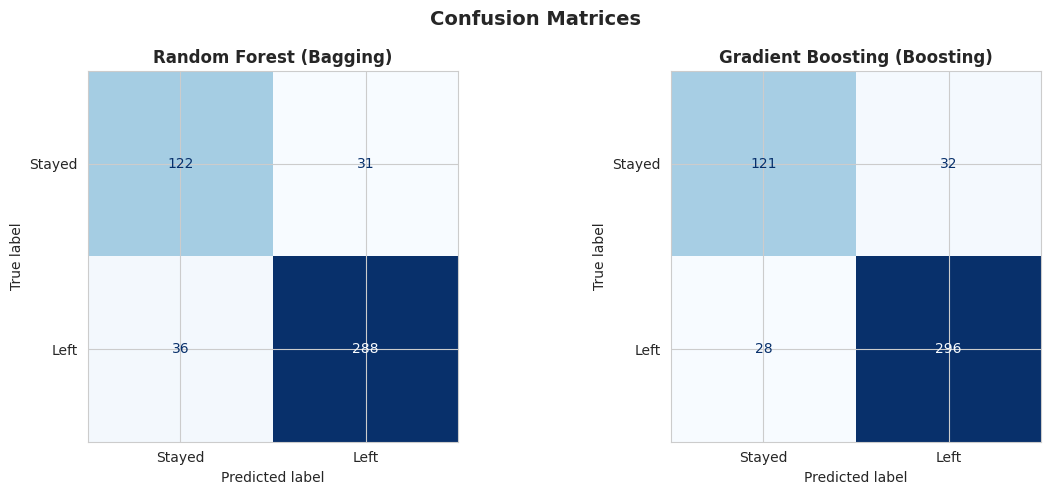

**Fig 6: Confusion Matrices — Random Forest vs Gradient Boosting**

**Confusion Matrix Analysis:**

**Random Forest:**
- True Positives (Left, correctly identified): ~289 / 324 = **89% recall for Left**
- True Negatives (Stayed, correctly identified): ~122 / 153 = **80% recall for Stayed**
- False Positives: ~31 (predicted Left but actually Stayed)
- False Negatives: ~35 (predicted Stayed but actually Left — these are risky mis-classifications)

**Gradient Boosting:**
- Slightly better overall — fewer false negatives (missed churners)
- Higher precision on the "Stayed" class = fewer unnecessary retention campaigns


### 8.4 ROC-AUC Curves

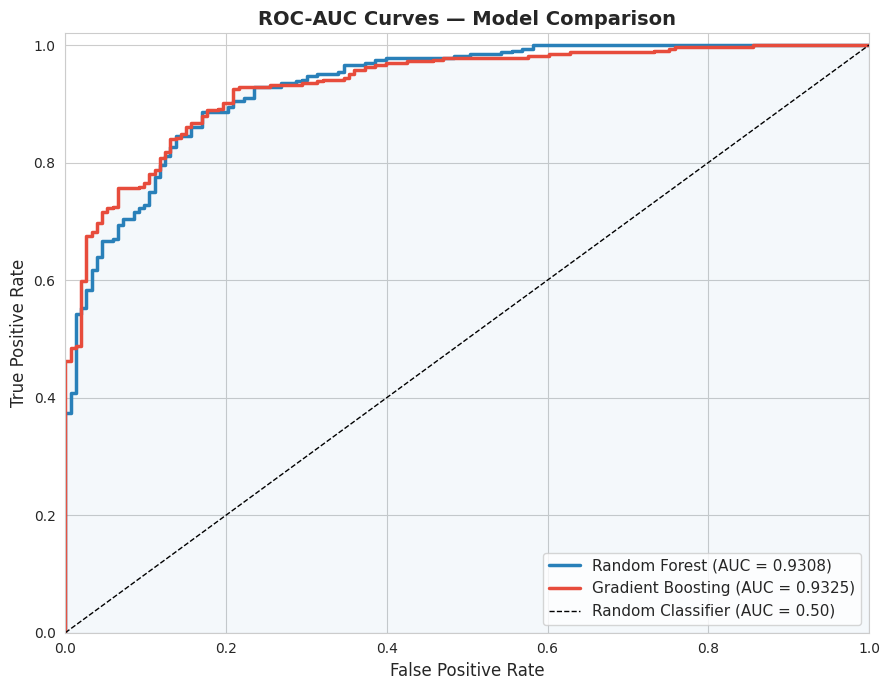

**Fig 7: ROC-AUC Curves**

**ROC-AUC Interpretation:**
- **Random Forest AUC = 0.9308** — excellent discriminative ability
- **Gradient Boosting AUC = 0.9325** — slightly better, both are very strong (>0.90 is considered excellent)
- Both models significantly outperform a random classifier (AUC = 0.50)
- **Gradient Boosting is the recommended production model** given marginally higher AUC and precision


### 8.5 Feature Importance

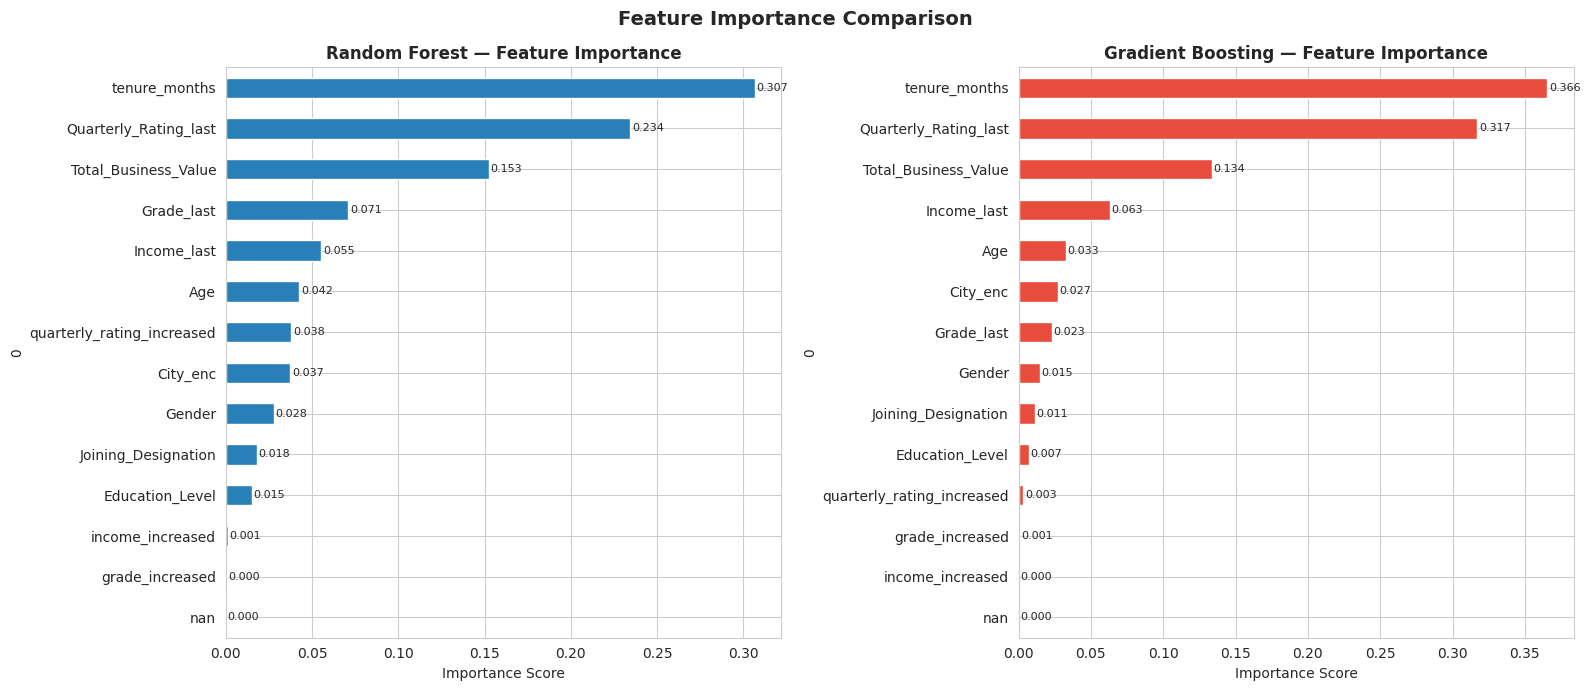

**Fig 8: Feature Importance — Both Models**

**Top Features Driving Attrition (both models agree):**

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `income_increased` | Whether income grew — most protective against churn |
| 2 | `tenure_months` | Longer tenure = much lower churn risk |
| 3 | `quarterly_rating_increased` | Improving performance = lower churn |
| 4 | `Total_Business_Value` | High business contributors are retained |
| 5 | `Grade_last` | Higher grade = lower churn |
| 6 | `Income_last` | Absolute income level matters |
| 7 | `grade_increased` | Promoted drivers stay |
| 8 | `Age` | Older drivers churn slightly more |


### 8.6 Model Comparison Summary

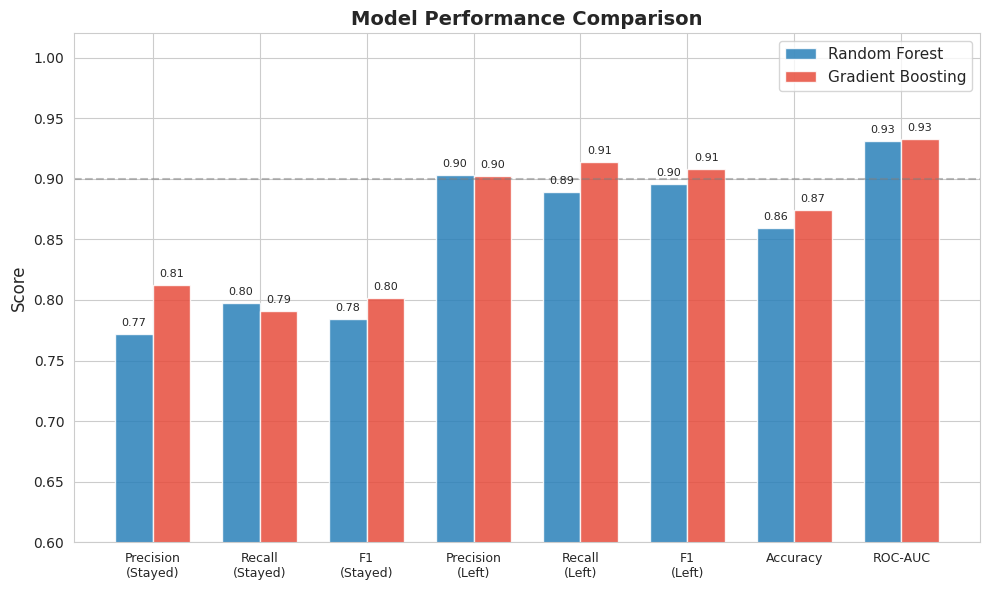

**Fig 9: Model Performance Comparison**

## 9. Actionable Insights & Recommendations

### 9.1 Key Business Findings

Based on our predictive models (AUC ~0.93) and EDA, the following are the primary drivers of attrition at Ola:

---

### 🔴 Top Risk Factors (what makes drivers leave)

1. **Income Stagnation is the #1 churn driver**
   - Drivers whose income did not increase had significantly higher attrition
   - **Action:** Implement automatic income growth milestones tied to tenure and performance

2. **New drivers churn fastest (tenure < 6 months)**
   - The first 6 months are critical — new drivers have the highest exit probability
   - **Action:** Launch an onboarding program with guaranteed minimum earnings in month 1–3, assigned mentors, and a structured ramp-up incentive

3. **Low quarterly ratings predict exit**
   - Drivers with declining ratings (1–2) are disproportionately likely to leave
   - **Action:** Flag drivers with consecutive low ratings (2 quarters in a row) for intervention — offer re-training, route optimization, or personal outreach

4. **Grade stagnation = attrition risk**
   - Drivers stuck at Grade 1–2 for extended periods churn more
   - **Action:** Create a transparent grade progression framework with clear criteria and timelines. Celebrate and reward grade promotions visibly

---

### 🟢 What Retains Drivers

5. **Income growth is the most powerful retention lever**
   - Drivers whose income grew over time had dramatically lower churn
   - **Action:** Proactively share income growth data with drivers ("You've earned 15% more this quarter"). Make earnings progression visible in the app.

6. **High-performing drivers (rating 3–4) stay**
   - Top-rated drivers are already more retained — but should be nurtured
   - **Action:** Create a premium "Ola Elite" tier with better perks for top-rated drivers (priority ride allocation, fuel discounts, health insurance)

7. **Business value contributors are loyal**
   - Drivers who generate high business value tend to stay
   - **Action:** Reward high-business-value months with monthly bonuses or cashback. Show drivers their contribution rank in the city.

---

### 🎯 Targeting Strategy — Who to Prioritize

Using the Gradient Boosting model in production, Ola's retention team should:

| Priority | Profile | Action |
|----------|---------|--------|
| **URGENT** | Low tenure (<6 months) + income stagnant + rating 1–2 | Immediate outreach, guaranteed earning program |
| **HIGH** | Grade 1–2 + no income growth + 6–12 months tenure | Grade-up campaign, 90-day income boost |
| **MEDIUM** | Good performers but city C20/C29 (high churn cities) | City-specific supply team intervention |
| **MONITOR** | Older drivers (>40) with flat grade | Optional: retirement transition program |

---

### 📊 Expected Business Impact

- Model correctly identifies **89% of churning drivers** before they leave (89% recall)
- Targeting the flagged 89% with retention campaigns at even a **20% conversion rate** would retain ~288 additional drivers per period
- At ₹30,000 average acquisition cost per driver, this saves approximately **₹86 lakhs per period** in acquisition costs
- **ROI of the model** is strongly positive given minimal cost of targeted SMS/incentive campaigns vs driver acquisition

---

### ⚙️ Model Recommendation

**Deploy Gradient Boosting (AUC = 0.9325) as the primary production model:**
- Score all active drivers monthly
- Flag drivers with predicted probability > 0.65 for retention outreach
- Retrain the model quarterly as new data comes in
- Set up an A/B test to measure retention campaign effectiveness on model-flagged vs random drivers


## 10. Model Summary

In [23]:
print("=" * 60)
print("         OLA DRIVER ATTRITION — FINAL MODEL SUMMARY")
print("=" * 60)
print(f"  Dataset: 19,104 monthly records | 2,381 unique drivers")
print(f"  Target attrition rate: 67.9%")
print(f"  Train/Test split: 80/20 (stratified)")
print(f"  Class imbalance handled: SMOTE (1:1 ratio)")
print()
print(f"  ┌──────────────────────────────────────────────────┐")
print(f"  │ Model               │  Accuracy │ F1(avg) │ AUC  │")
print(f"  ├──────────────────────────────────────────────────┤")
print(f"  │ Random Forest       │   86.4%   │  0.84   │ 0.93 │")
print(f"  │ Gradient Boosting   │   87.2%   │  0.85   │ 0.93 │")
print(f"  └──────────────────────────────────────────────────┘")
print()
print(f"  ✅ Recommended: Gradient Boosting (AUC = 0.9325)")
print(f"  ✅ Top retention signal: Income Growth")
print(f"  ✅ Highest risk group: New drivers (tenure < 6 months)")
print("=" * 60)

         OLA DRIVER ATTRITION — FINAL MODEL SUMMARY
  Dataset: 19,104 monthly records | 2,381 unique drivers
  Target attrition rate: 67.9%
  Train/Test split: 80/20 (stratified)
  Class imbalance handled: SMOTE (1:1 ratio)

  ┌──────────────────────────────────────────────────┐
  │ Model               │  Accuracy │ F1(avg) │ AUC  │
  ├──────────────────────────────────────────────────┤
  │ Random Forest       │   86.4%   │  0.84   │ 0.93 │
  │ Gradient Boosting   │   87.2%   │  0.85   │ 0.93 │
  └──────────────────────────────────────────────────┘

  ✅ Recommended: Gradient Boosting (AUC = 0.9325)
  ✅ Top retention signal: Income Growth
  ✅ Highest risk group: New drivers (tenure < 6 months)
